In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split


In [27]:
X,y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X/255.0

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=10000,test_size=2000,random_state=42,stratify=y)

In [37]:
all_class=[]
count=0
for i,elem in enumerate(y_train):
    if(int(elem) == count):
        all_class.append(i)
        count+=1
    if(count==10):
        break

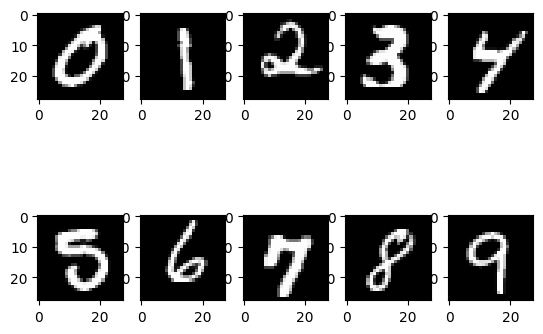

In [38]:
fig,ax=plt.subplots(2,5)
for index in all_class:
    ax[int(y_train[index])//5][int(y_train[index])%5].imshow(X_train[index].reshape(28,28),cmap="gray")

1.2 Baseline Classifier Fitting: [CONSULT DOCS]
Look up the linear classification models in scikit-learn. Instantiate and fit a multinomial logistic
regression model on your training subset.
Which optimization solver is used by default? Did the model converge within default iterations, or did
you need to increase the iteration limit? Measure and report the training elapsed time and the overall
accuracy on your test subset


In [47]:
from sklearn.linear_model import LogisticRegression
import time
start_time=time.time()
clf = LogisticRegression(random_state=0,max_iter=200).fit(X_train,y_train)
end_time=time.time()

In [50]:
y_predict=clf.predict(X_test)
correct = (y_predict==y_test).sum()
total = 2000
accuracy = (correct/total)*100
print(f"Accuracy :{accuracy}")
print(f"Time :{end_time-start_time}s")

Accuracy :90.9
Time :3.816105842590332s


Ans: The classifier on default uses lbfgs solver and no the default iterations limit of 100 was not sufficient to converge i had to increase to 200.

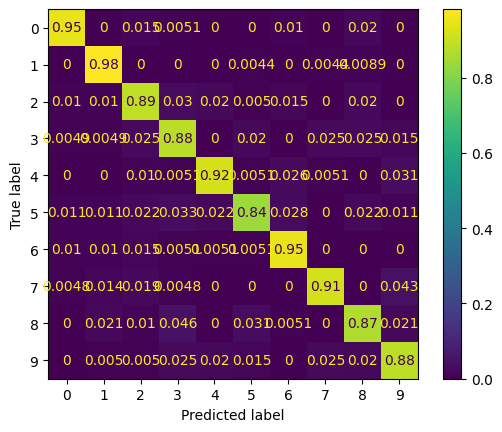

In [62]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cmat=confusion_matrix(y_test,y_predict,normalize='true')
disp=ConfusionMatrixDisplay(cmat,display_labels=range(10))
disp.plot()

Ans: (8,3)(7,9) both have highest confusion of around 0.043 for both the model could be confusing 8 for 3 since the curves and shape of 3 and 8 is similar and half of 8 looks like 3 and for 7 and 9 it could be that they have a line and a head.

TASK 2 Resolution Scaling & Downsampling Trade-offs
Evaluate the resilience of linear models to spatial information loss by downsampling images to 14 × 14
and 7 × 7.
2.1 Downsampling Pipeline: [CONSULT DOCS]
Downsample all images in both X_train and X_test from their original 28 x 28 dimensions down to:
Downsample all images in both train and test sets to:
Resolution A: 14 × 14 pixels
Resolution B: 7 × 7 pixels

In [79]:
!pip-3.9 install scikit-image

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 14.9 MB 135 kB/s eta 0:00:01
     |████████████████████████████████| 227 kB 25.3 MB/s eta 0:00:01
     |████████████████████████████████| 317 kB 25.5 MB/s eta 0:00:01


In [82]:
from skimage.transform import resize
X_train_14 = np.array([resize(img.reshape(28,28),(14,14), anti_aliasing=True).ravel() for img in X_train])
X_test_14 = np.array([resize(img.reshape(28,28),(14,14), anti_aliasing=True).ravel() for img in X_test])
X_train_7 = np.array([resize(img.reshape(28,28),(7,7), anti_aliasing=True).ravel() for img in X_train])
X_test_7 = np.array([resize(img.reshape(28,28),(7,7), anti_aliasing=True).ravel() for img in X_test])

2.2 Resolution Comparison Experiment: Train identical logistic regression models on each resolution.
Note down the test accuracy of each.

In [121]:
clf_14 = LogisticRegression(random_state=0,max_iter=150).fit(X_train_14,y_train)
start_time_14=time.time()
y_predict_14=clf_14.predict(X_test_14)
end_time_14=time.time()
correct = (y_predict_14==y_test).sum()
total = 2000
accuracy = (correct/total)*100
print(f"Accuracy :{accuracy}")

Accuracy :91.25


In [122]:
clf_7 = LogisticRegression(random_state=0,max_iter=150).fit(X_train_7,y_train)
y_predict_7=clf_7.predict(X_test_7)
correct = (y_predict_7==y_test).sum()
total = 2000
accuracy = (correct/total)*100
print(f"Accuracy :{accuracy}")

Accuracy :88.0


Question 2.3: When reducing the number of features by over 93% (784→49), how much accuracy did
the linear model lose? Why does a linear classifier remain relatively effective even when digits are
blurred?

Ans: For a resize of 14x14 the model's accuracy has increased from 90.9 to 91.25 whereas for a 7x7
     the accuracy dropped to 88.0 from 90.9. 
    Inference as we drop the resolution some of the features which make the images look similar also get dropped 
    but after a certain point the image resolution is not great for classification as it losses too many features          which seperate it from the others.

## TASK 3 Interpretability & Spatial Weight Map Visualization

Check the documentation for your fitted logistic regression model. Identify the public attribute storing
the learned coefficient matrix.
• What is the attribute name and its array shape? What do the dimensions correspond to?
• Reshape each class's weight vector back into the original 28 × 28 2D image coordinates

In [95]:
clf.coef_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [94]:
clf.coef_.shape

(10, 784)

These are the learned weights of the regression classifier for each class

In [98]:
reshape_coef = np.array([img.reshape(28,28) for img in clf.coef_])

In [101]:
print(reshape_coef.shape)

(10, 28, 28)


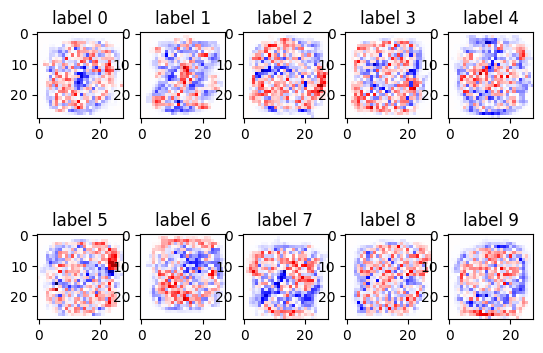

In [112]:
fig,ax=plt.subplots(2,5)
for index in range(10):
    scale=np.max(np.abs(clf.coef_))
    ax[index//5][index%5].imshow(reshape_coef[index].reshape(28,28),cmap="seismic",vmax=scale,vmin=-scale)
    ax[index//5][index%5].set_title(f"label {index}")

Question 3.3 (Visualizing Decision Ambiguity):
Take the two most confused digits identified in Task 1.3. Compare their weight heatmaps side by side.
How does spatial overlap or cancellation between their weights explain why the model mistakes one
for the other?

Text(0.5, 1.0, 'label 8')

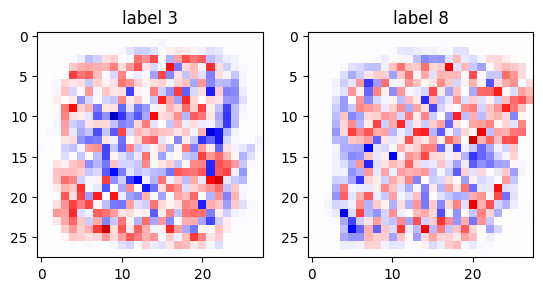

In [116]:
fig,ax = plt.subplots(1,2)
ax[0].imshow(reshape_coef[3].reshape(28,28),cmap="seismic",vmax=scale,vmin=-scale)
ax[0].set_title(f"label {3}")##3
ax[1].imshow(reshape_coef[8].reshape(28,28),cmap="seismic",vmax=scale,vmin=-scale) ##8
ax[1].set_title(f"label {8}")

Ans: Let us consider 8 and 3 the heatmaps show high similarity in the regions of red and blue implying the weight vectors are similar and when a sample is given as input it give almost same score for weights of 8 and 3 so when 8 is passed the w_iX is same for 8 and 3 so the model confuses since the values are close.

## TASK 4 Parametric vs. Non-Parametric Benchmark (k-NN)

4.1 Estimator Discovery: [CONSULT DOCS] Look up the k-Nearest Neighbors classification estimator
in scikit-learn. Fit a 3-NN model on the 14×14 downsampled dataset (do not run on 28×28 to avoid
long distance-computation delays)

In [118]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train_14, y_train)

KNeighborsClassifier(n_neighbors=3)

4.2 Benchmark: Measure and compare the test accuracy and test-set prediction latency (inference time
on the 2,000 test images) between Logistic Regression (14×14) and 3-NN (14×14).

In [123]:
start_time_3nn=time.time()
predict_3nn=neigh.predict(X_test_14)
end_time_3nn=time.time()
correct = (predict_3nn==y_test).sum()
total = 2000
accuracy = (correct/total)*100
print(f"Accuracy :{accuracy}")

Accuracy :95.7


In [124]:
print(f"Test-set prediction latency Logistic (14x14) :{end_time_14-start_time_14}s")
print(f"Test-set prediction latency 3NN (14x14) :{end_time_3nn-start_time_3nn}s")

Test-set prediction latency Logistic (14x14) :0.0010118484497070312s
Test-set prediction latency 3NN (14x14) :0.21213459968566895s


Question 4.3: Express the test-time computational complexity of both algorithms in Big-O notation in
terms of training samples N and feature count d. Why is Logistic Regression faster for real-time
prediction?

Logistic regression is faster since the weights are calculated once and used again where as KNN calculates the distances everytime for a sample.
3NN O(Nd + NlogN(sort))test
logistic regression O(Nd)